# Анализ отклонений: сезонность, тренд и выбор прогнозной модели

**Управленческий вопрос.** Объём операций портфеля растёт или падает —
и какому из трёх противоречащих друг другу ответов верить?

Код тетради написан ассистентом по промпту из файла
[`3.4.1_промпт.md`](3.4.1_промпт.md) и принят по проверкам — правки разобраны
в конце тетради. Данные — дневной
ряд объёма операций за три с половиной года. Один и тот же ряд даст три
разных ответа
в зависимости от того, как на него посмотреть, — в этом и состоит кейс.

In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

%matplotlib inline
matplotlib.rcParams["font.size"] = 11
ACC, WARN, INK, BLUE = "#20BA72", "#E4572E", "#2E3641", "#1B7FD6"


def оформить(ax, заголовок, x=None, y=None):
    ax.set_title(заголовок, fontsize=12.5, pad=12, fontweight="bold", color=INK)
    if x: ax.set_xlabel(x, fontsize=10.5)
    if y: ax.set_ylabel(y, fontsize=10.5)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(alpha=0.25)

## Метод 1. Линия тренда по исходному ряду

Самый частый способ ответить на вопрос «растём или падаем» — месячные суммы
и линия тренда по ним.

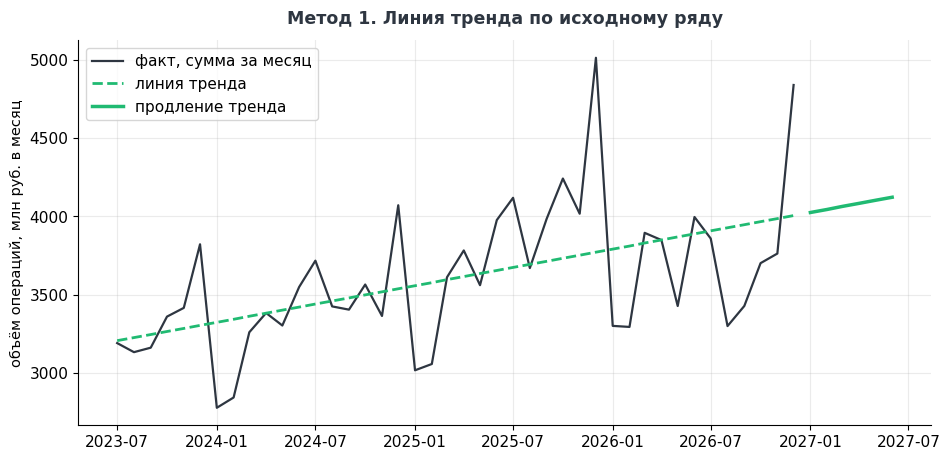

Наклон тренда: +19.5 млн руб. в месяц — рост +6.5% в год


In [2]:
ряд = pd.read_csv("../data/series/portfolio_operations_daily.csv",
                  sep=";", decimal=",", encoding="utf-8-sig",
                  parse_dates=["дата"], index_col="дата")["объём_операций_млн_руб"]

месяцы = ряд.resample("MS").sum()

x = np.arange(len(месяцы))
к, с = np.polyfit(x, месяцы.values, 1)
будущее_x = np.arange(len(месяцы), len(месяцы) + 6)
будущее_даты = pd.date_range(месяцы.index[-1] + pd.DateOffset(months=1),
                             periods=6, freq="MS")

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(месяцы.index, месяцы.values, color=INK, lw=1.6, label="факт, сумма за месяц")
ax.plot(месяцы.index, к * x + с, color=ACC, lw=2, ls="--", label="линия тренда")
ax.plot(будущее_даты, к * будущее_x + с, color=ACC, lw=2.5,
        label="продление тренда")
ax.legend()
оформить(ax, "Метод 1. Линия тренда по исходному ряду",
         y="объём операций, млн руб. в месяц")
plt.show()
print(f"Наклон тренда: {к:+.1f} млн руб. в месяц — рост {к * 12 / месяцы.mean():+.1%} в год")

Линия уверенно идёт вверх, продление обещает рост и дальше. На этом месте
отчёт обычно и заканчивается. Продолжим.

## Метод 2. Удаление сезонности

В дневном ряде наложены три регулярных ритма: месяц года, начало и конец
месяца, день недели. Пока они в данных, тренд читается неверно: сильный
сезонный месяц в конце ряда выглядит как рост.

Коэффициент сезонности — отношение среднего значения в позиции (месяц года,
день месяца, день недели) к общему среднему. Деление на коэффициент убирает
ритм из ряда. Снимаем по одному циклу за раз, от самого длинного к самому
короткому, и смотрим, что меняется после каждого шага.

Годовые коэффициенты считаем не к общему среднему, а к скользящему среднему
за 12 месяцев — иначе при выраженном тренде поздние месяцы получают
завышенный коэффициент просто потому, что они поздние.

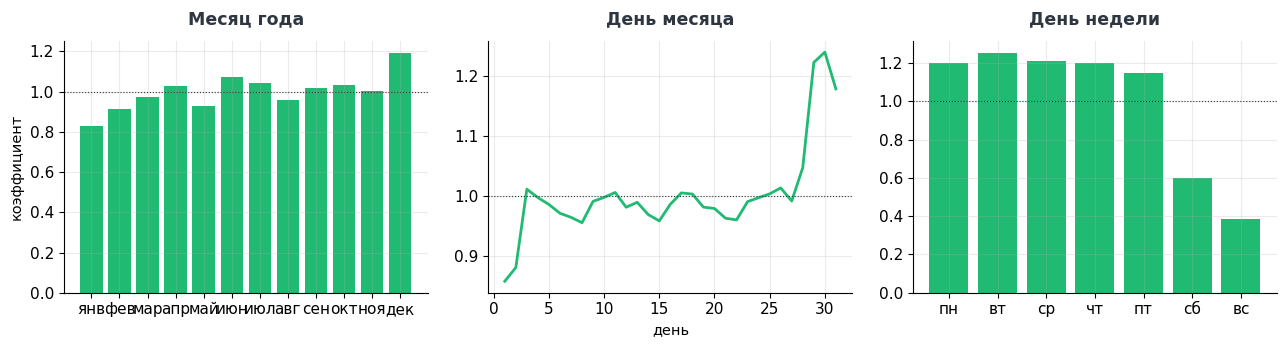

In [3]:
# 1. годовая: коэффициент месяца года — к скользящему среднему за 12 месяцев
мес_сырой = ряд.resample("MS").mean()
скользящее = мес_сырой.rolling(12, center=True, min_periods=12).mean()
отношение = (мес_сырой / скользящее).dropna()
к_года = отношение.groupby(отношение.index.month).mean()
к_года = к_года / к_года.mean()
без_года = ряд / к_года[ряд.index.month].values

# 2. внутримесячная: коэффициент дня месяца
к_дня = без_года.groupby(без_года.index.day).mean() / без_года.mean()
без_дня = без_года / к_дня[без_года.index.day].values

# 3. недельная: коэффициент дня недели
к_недели = без_дня.groupby(без_дня.index.dayofweek).mean() / без_дня.mean()
без_недели = без_дня / к_недели[без_дня.index.dayofweek].values

# месячный ряд: среднедневной объём — не зависит от числа дней в месяце
очищенный = без_недели.resample("MS").mean()

СЛОИ = [("как есть", ряд), ("снята годовая", без_года),
        ("снята внутримесячная", без_дня), ("снята недельная", без_недели)]

дни_нед = ["пн", "вт", "ср", "чт", "пт", "сб", "вс"]
мес_имена = ["янв", "фев", "мар", "апр", "май", "июн",
             "июл", "авг", "сен", "окт", "ноя", "дек"]
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
axes[0].bar(мес_имена, к_года.values, color=ACC)
оформить(axes[0], "Месяц года", y="коэффициент")
axes[1].plot(к_дня.index, к_дня.values, color=ACC, lw=2)
оформить(axes[1], "День месяца", x="день")
axes[2].bar(дни_нед, к_недели.values, color=ACC)
оформить(axes[2], "День недели")
for ax in axes: ax.axhline(1, color=INK, lw=0.8, ls=":")
plt.tight_layout(); plt.show()

Все три ритма на месте: декабрь сильнее прочих месяцев, последние дни
месяца дают всплеск, выходные втрое ниже будней.

Теперь — главная картинка блока: тот же ряд четырьмя панелями, из которых
последовательно убран каждый цикл. На каждой панели две линии: месячное
среднее (без него дневная пила заслоняет всё остальное) и прямая тренда
за последние двенадцать месяцев.

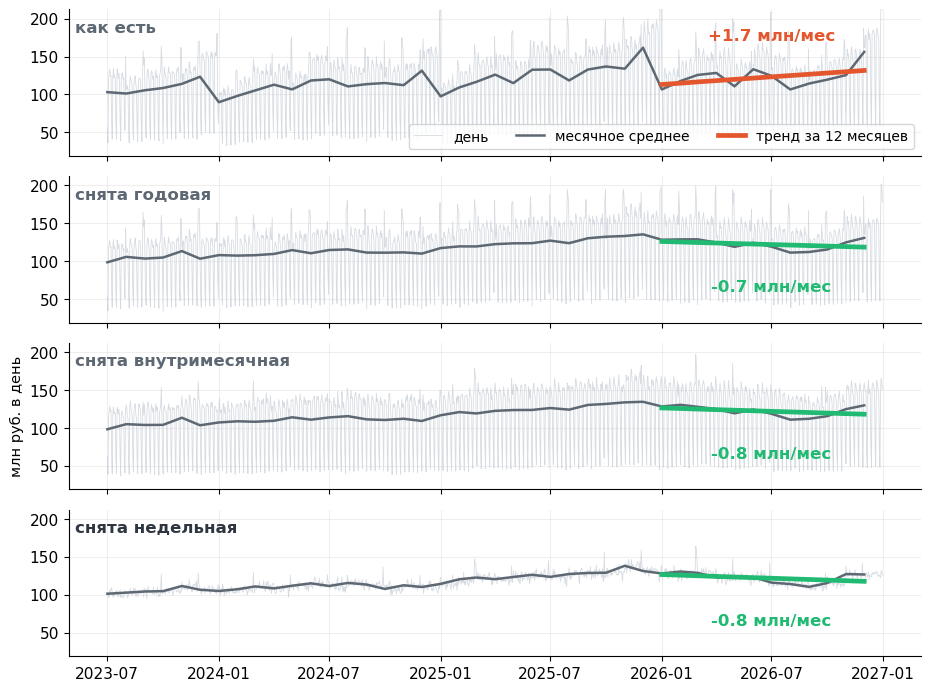

In [4]:
ОКНО = 12          # одно и то же окно на всех панелях — иначе сравнение нечестно

fig, axes = plt.subplots(len(СЛОИ), 1, sharex=True, figsize=(11, 8.4))
все = np.concatenate([с.values for _, с in СЛОИ])
низ, верх = все.min(), np.percentile(все, 99.7)
поле = (верх - низ) * 0.08

for i, (ax, (подпись, слой)) in enumerate(zip(axes, СЛОИ)):
    последний = i == len(СЛОИ) - 1
    ax.plot(слой.index, слой.values, color="#c2cad3", lw=0.6, alpha=0.65,
            label="день" if i == 0 else None)
    уровень = слой.resample("MS").mean()
    ax.plot(уровень.index, уровень.values, color="#5d6873", lw=1.8,
            label="месячное среднее" if i == 0 else None)

    хвост = уровень.tail(ОКНО)
    наклон, сдвиг = np.polyfit(np.arange(ОКНО), хвост.values, 1)
    цвет = WARN if наклон > 0 else ACC
    ax.plot(хвост.index, наклон * np.arange(ОКНО) + сдвиг, color=цвет, lw=3.4,
            label=f"тренд за {ОКНО} месяцев" if i == 0 else None)
    ax.annotate(f"{наклон:+.1f} млн/мес",
                xy=(хвост.index[ОКНО // 2], наклон * (ОКНО // 2) + сдвиг),
                xytext=(0, 26 if наклон > 0 else -34), textcoords="offset points",
                ha="center", fontsize=12, fontweight="bold", color=цвет)

    if i == 0:
        ax.legend(loc="lower right", ncol=3, fontsize=10)
    ax.set_ylim(низ - поле, верх + поле)
    ax.text(0.008, 0.845, подпись, transform=ax.transAxes, fontsize=12,
            fontweight="bold", color=INK if последний else "#5d6873")
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(alpha=0.2)
axes[len(СЛОИ) // 2].set_ylabel("млн руб. в день", fontsize=10.5)
fig.subplots_adjust(hspace=0.14)
plt.show()

Главное на этой картинке — прямая тренда, и считается она **в одном
и том же окне** на всех четырёх панелях. На исходном ряде она идёт вверх;
после снятия годовой сезонности та же прямая за тот же период идёт вниз.

Это и есть цена вопроса. Отчёт готовится в январе, последние двенадцать
месяцев — от самого слабого сезонного месяца к самому сильному, и одна
только годовая сезонность добавляет к наклону около трёх миллионов в день
за месяц. Она перекрывает реальное снижение уровня с запасом, поэтому
исходный ряд показывает рост там, где портфель снижается.

Два следующих шага меняют наклон незначительно: внутримесячные и недельные
колебания внутри месяца взаимно погашаются. Убирать их всё равно нужно —
но не ради тренда, а ради чтения дневного ряда, на котором принимаются
оперативные решения.

Тот же переход, наложенный на одно полотно, — видно, как линия уровня
распрямляется шаг за шагом.

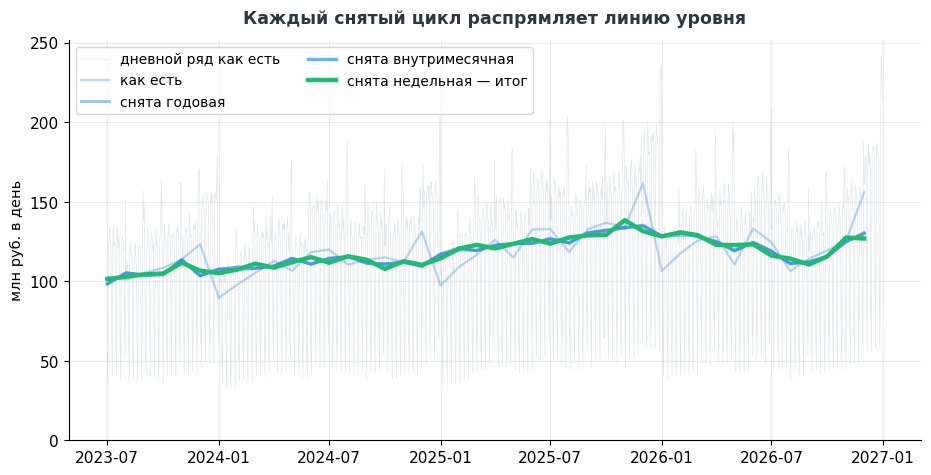

In [5]:
fig, ax = plt.subplots(figsize=(11, 5.2))
ax.plot(ряд.index, ряд.values, color="#9aa5b1", lw=0.5, alpha=0.28,
        label="дневной ряд как есть")
for (подпись, слой), альфа, лв in zip(СЛОИ[:-1], [0.30, 0.46, 0.62], [1.6, 2.0, 2.4]):
    уровень = слой.resample("MS").mean()
    ax.plot(уровень.index, уровень.values, color="#1B7FD6", lw=лв, alpha=альфа,
            label=подпись)
ax.plot(очищенный.index, очищенный.values, color=ACC, lw=3.2,
        label="снята недельная — итог")
ax.set_ylim(bottom=0)
ax.legend(loc="upper left", ncol=2, fontsize=10)
оформить(ax, "Каждый снятый цикл распрямляет линию уровня", y="млн руб. в день")
plt.show()

Две последние линии почти совпадают — и это содержательный результат,
а не изъян расчёта: внутримесячные и недельные колебания внутри месяца
взаимно погашаются, поэтому на месячный уровень они почти не влияют. Мешают
они другому — чтению дневного ряда, а на нём принимаются оперативные решения.

Уровень определяет годовая сезонность: до её снятия линия ныряет каждый
январь, и любой вывод, сделанный по двум соседним месяцам, оказывается
разговором о календаре, а не о портфеле.

Теперь — очищенный ряд и тренд по последнему году.

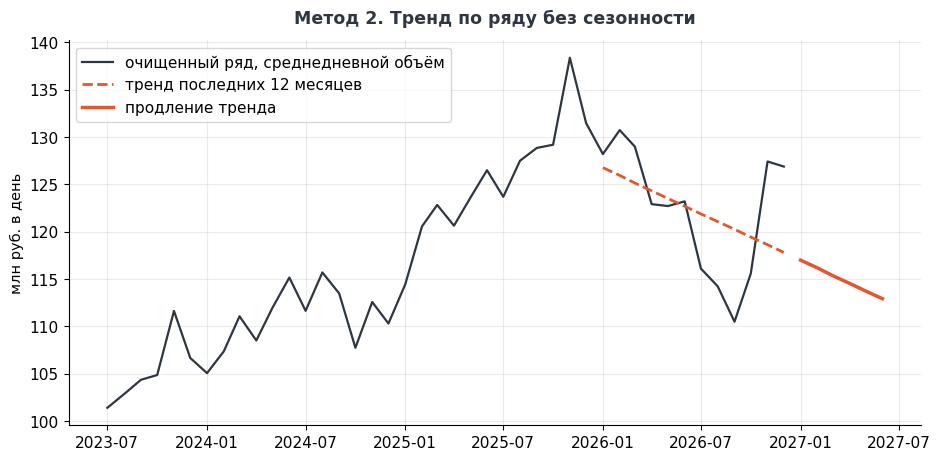

Наклон тренда за последний год: -0.81 млн руб. в день за месяц


In [6]:
x12 = np.arange(12)
последние12 = очищенный.tail(12)
к12, с12 = np.polyfit(x12, последние12.values, 1)

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(очищенный.index, очищенный.values, color=INK, lw=1.6,
        label="очищенный ряд, среднедневной объём")
ax.plot(последние12.index, к12 * x12 + с12, color=WARN, lw=2, ls="--",
        label="тренд последних 12 месяцев")
ax.plot(будущее_даты, к12 * np.arange(12, 18) + с12, color=WARN, lw=2.5,
        label="продление тренда")
ax.legend()
оформить(ax, "Метод 2. Тренд по ряду без сезонности",
         y="млн руб. в день")
plt.show()
print(f"Наклон тренда за последний год: {к12:+.2f} млн руб. в день за месяц")

Тот же ряд — противоположный вывод: без сезонного глянца последний год
идёт вниз. Просадка началась одиннадцать месяцев назад, и продление её
тренда обещает дальнейшее падение.

Но у второго взгляда то же слабое место, что у первого: линейный тренд
по фиксированному окну не знает ничего, кроме наклона. Проверим модели
по-честному — на способности предсказывать.

## Метод 3. Прогнозные модели на скользящей проверке

Правило одно: модель хороша не тем, что нравится, а тем, что предсказывала
лучше других. Скользящая проверка: из каждой точки последнего года строится
прогноз на 3 месяца вперёд только по данным до этой точки, прогноз
сравнивается с фактом. Модели три:

- **линейный тренд** по последним 12 месяцам;
- **сезонная наивная**: значение того же месяца год назад плюс средний
  годовой прирост (на очищенном ряде — просто прошлогоднее значение
  с поправкой);
- **сглаживание Холта**: уровень и тренд обновляются с каждым месяцем,
  свежие наблюдения весят больше давних.

У последней модели два параметра — насколько сильно свежее наблюдение
двигает уровень и насколько сильно оно двигает тренд. Их не назначают
на глаз: перебираем несколько пар на той же скользящей проверке
и берём пару с наименьшей ошибкой.

In [7]:
def прогноз_линейный(история, горизонт):
    окно = история[-12:]
    к, с = np.polyfit(np.arange(len(окно)), окно, 1)
    return к * np.arange(len(окно), len(окно) + горизонт) + с


def прогноз_наивный_сезонный(история, горизонт):
    прирост = (история[-1] - история[-13]) if len(история) >= 13 else 0
    return np.array([история[len(история) - 12 + h] + прирост
                     for h in range(горизонт)])


def прогноз_холта(история, горизонт, альфа=0.8, бета=0.05):
    уровень, тренд = история[0], история[1] - история[0]
    for з in история[1:]:
        уровень, прежний = альфа * з + (1 - альфа) * (уровень + тренд), уровень
        тренд = бета * (уровень - прежний) + (1 - бета) * тренд
    return np.array([уровень + тренд * (h + 1) for h in range(горизонт)])


ГОРИЗОНТ = 3
значения = очищенный.values


# средняя абсолютная ошибка на скользящей проверке последнего года
def проверить(модель):
    ошибки = [np.abs(модель(значения[:т], ГОРИЗОНТ)
                     - значения[т:т + ГОРИЗОНТ]).mean()
              for т in range(len(значения) - 12, len(значения) - ГОРИЗОНТ + 1)]
    return np.mean(ошибки), ошибки


# параметры сглаживания подбираются на той же проверке
сетка = sorted((проверить(lambda и, г, a=a, b=b: прогноз_холта(и, г, a, b))[0], a, b)
               for a in (0.3, 0.5, 0.7, 0.8) for b in (0.05, 0.1, 0.2))
_, АЛЬФА, БЕТА = сетка[0]
print(f"Параметры сглаживания, выбранные по ошибке: "
      f"вес свежего значения {АЛЬФА}, вес изменения тренда {БЕТА}")

МОДЕЛИ = {
    "линейный тренд (12 мес)": прогноз_линейный,
    "сезонная наивная": прогноз_наивный_сезонный,
    "сглаживание Холта": lambda и, г: прогноз_холта(и, г, АЛЬФА, БЕТА),
}
ошибки = {}
таблица = {}
for имя, модель in МОДЕЛИ.items():
    таблица[имя], ошибки[имя] = проверить(модель)

таблица = (pd.Series(таблица, name="средняя абсолютная ошибка, млн руб. в день")
           .sort_values().round(2).to_frame())
таблица

Параметры сглаживания, выбранные по ошибке: вес свежего значения 0.8, вес изменения тренда 0.2


,"средняя абсолютная ошибка, млн руб. в день"
сглаживание Холта,6.46
сезонная наивная,7.50
линейный тренд (12 мес),9.49


## Ползунок: прогнозы из прошлых точек старта

Средняя ошибка из таблицы — итог по многим прогонам; диаграмма ниже
показывает отдельные прогоны. Ползунок ниже ставит точку старта в один из месяцев
последнего года. Из этой точки каждая модель строит прогноз на три месяца
вперёд **только по данным слева от точки** — а сплошная линия показывает,
что случилось на самом деле. В заголовке — ошибка каждой модели на этом
конкретном старте.

Подвигайте ползунок по всем стартам. На большинстве из них прогноз
сглаживания ложится к факту плотнее остальных; линейный тренд
систематически промахивается вокруг перелома. Есть и старты, где
сглаживание проигрывает — у самого дна разворота, который ни одна модель
не могла увидеть по прошлому. Именно поэтому модель выбирается
не по удачной точке, а по средней ошибке всех стартов — это и делает
следующий шаг.

In [8]:
import plotly.graph_objects as go

ЦВЕТА_МОДЕЛЕЙ = {"линейный тренд (12 мес)": WARN,
                 "сезонная наивная": BLUE,
                 "сглаживание Холта": ACC}
СТАРТЫ = list(range(len(значения) - 12, len(значения) - ГОРИЗОНТ + 1))
даты = очищенный.index

fig = go.Figure()
# факт — всегда виден
fig.add_trace(go.Scatter(x=даты[-20:], y=значения[-20:], mode="lines+markers",
                         name="факт", line=dict(color=INK, width=2),
                         marker=dict(size=5)))

подписи = []
for т in СТАРТЫ:
    ошибки_старта = {}
    for имя, модель in МОДЕЛИ.items():
        пр = модель(значения[:т], ГОРИЗОНТ)
        ошибки_старта[имя] = np.abs(пр - значения[т:т + ГОРИЗОНТ]).mean()
        fig.add_trace(go.Scatter(
            x=даты[т - 1:т + ГОРИЗОНТ],
            y=np.concatenate([[значения[т - 1]], пр]),
            mode="lines+markers", name=имя, visible=False,
            line=dict(color=ЦВЕТА_МОДЕЛЕЙ[имя], width=2.5, dash="dot"),
            marker=dict(size=6)))
    # вертикальная метка старта
    fig.add_trace(go.Scatter(
        x=[даты[т - 1], даты[т - 1]],
        y=[min(значения[-20:]) * 0.98, max(значения[-20:]) * 1.02],
        mode="lines", visible=False, showlegend=False,
        line=dict(color=INK, width=1, dash="dash")))
    подписи.append("   ·   ".join(
        f"{имя.split()[0]} {ошибки_старта[имя]:.1f}".replace(".", ",")
        for имя in МОДЕЛИ))

НА_СТАРТ = len(МОДЕЛИ) + 1          # столько следов у каждого положения ползунка
шаги = []
for i, т in enumerate(СТАРТЫ):
    видимость = [True] + [False] * (len(СТАРТЫ) * НА_СТАРТ)
    for j in range(НА_СТАРТ):
        видимость[1 + i * НА_СТАРТ + j] = True
    шаги.append(dict(
        method="update", label=str(даты[т - 1])[:7],
        args=[{"visible": видимость},
              {"title.text": "Прогнозы из точки " + str(даты[т - 1])[:7]
                             + " — ошибка, млн руб. в день: " + подписи[i]}]))

# стартовое положение — первый старт
for j in range(НА_СТАРТ):
    fig.data[1 + j].visible = True

fig.update_layout(
    sliders=[dict(active=0, steps=шаги, pad=dict(t=34),
                  currentvalue=dict(prefix="точка старта: "))],
    title=dict(text="Прогнозы из точки " + str(даты[СТАРТЫ[0] - 1])[:7]
                    + " — ошибка, млн руб. в день: " + подписи[0],
               font=dict(size=14, color=INK)),
    height=520, template="simple_white",
    legend=dict(orientation="h", y=1.12),
    margin=dict(l=40, r=20, t=90, b=10),
    yaxis_title="объём операций, млн руб. в день")
fig.show()

Проверка на отложенных периодах сравнивает модели по средней ошибке.
Далее — прогноз модели с наименьшей ошибкой.

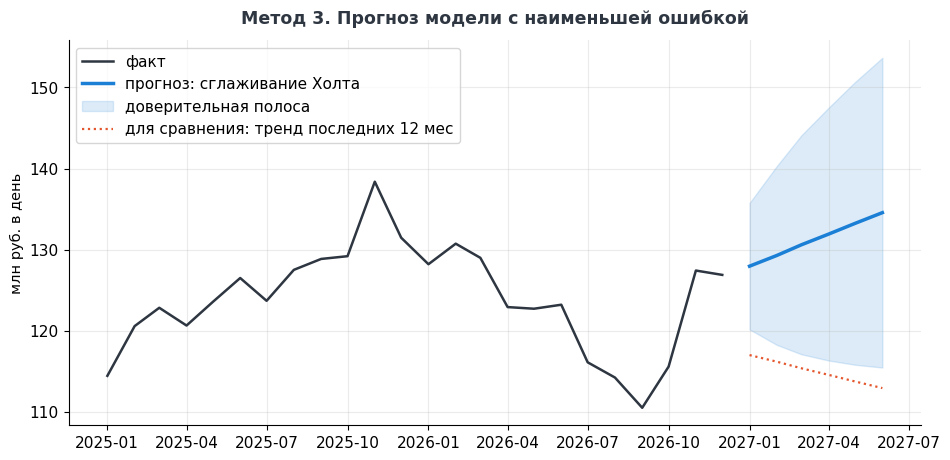

In [9]:
лучшая_имя = таблица.index[0]
лучшая = МОДЕЛИ[лучшая_имя]
прогноз = лучшая(значения, 6)

# ширина полосы — из ошибок этой модели на скользящей проверке,
# расширяется с горизонтом
сигма = np.std(ошибки[лучшая_имя]) + np.mean(ошибки[лучшая_имя])
полоса = 1.28 * сигма * np.sqrt(np.arange(1, 7) / ГОРИЗОНТ)

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(очищенный.index[-24:], значения[-24:], color=INK, lw=1.8, label="факт")
ax.plot(будущее_даты, прогноз, color=BLUE, lw=2.5, label=f"прогноз: {лучшая_имя}")
ax.fill_between(будущее_даты, прогноз - полоса, прогноз + полоса,
                color=BLUE, alpha=0.15, label="доверительная полоса")
ax.plot(будущее_даты, к12 * np.arange(12, 18) + с12, color=WARN, lw=1.6, ls=":",
        label="для сравнения: тренд последних 12 мес")
ax.legend()
оформить(ax, "Метод 3. Прогноз модели с наименьшей ошибкой",
         y="млн руб. в день")
plt.show()

## Три метода — три вывода: сравнение

| Взгляд | Метод | Вывод |
|---|---|---|
| Первый | тренд по сырому ряду | «растём» — сезонность выдана за рост |
| Второй | тренд по очищенному году | «падаем» — прямая не видит перелома |
| Третий | модель с лучшей ошибкой на отложенных периодах | просадка заканчивается, идёт восстановление |

Ни один из трёх не является истиной: у третьего просто есть то, чего нет
у первых двух, — измеренная ошибка. Правильная форма вывода для доклада:
«просадка началась полгода назад, последние месяцы восстанавливаются;
модель с лучшей проверенной точностью ожидает выход на уровень начала года
с такой-то полосой неопределённости».

**Вопросы к любому прогнозу до принятия решения:** на каких данных проверялась
модель и какова её ошибка на отложенном периоде; что будет, если реализуется
нижняя граница полосы; какое событие вызвало просадку и учтено ли его
повторение; когда прогноз пересчитывается.

## Правки к коду ассистента

Структуру решения — сезонные коэффициенты, скользящая проверка, выбор
модели по ошибке — ассистент предложил верно. Исправлений шесть, и почти все
из разряда тихих: код выглядел законченным.

1. **Деление рядов с разными индексами.** Дневной ряд делился на семь
   недельных коэффициентов напрямую; pandas выравнивает такие ряды по
   индексу, и результат превращается в пустоту. Исправление — подстановка
   коэффициентов по позициям (`.values`).
2. **Скользящая проверка от сегодняшней даты.** Ассистент отсчитывал окна
   от текущего дня запуска, а не от конца ряда: результат менялся бы от
   запуска к запуску и опирался на неполные окна.
3. **Позиционное обращение к ряду с датами** (`data[i]`) — в текущем pandas
   это обращение по метке, код падает; нужно `.iloc[i]`.
4. **Параметры сглаживания назначены на глаз.** В ответе стояли фиксированные
   значения без обоснования; они подбираются на той же скользящей проверке,
   что и выбор модели.
5. **Сезонности снимались в произвольном порядке и без проверки эффекта.**
   Порядок влияет на результат слабо (на этих данных — до трёх процентов),
   но каждый шаг должен быть виден: без промежуточных графиков нельзя сказать,
   что именно убрал расчёт.
6. **Годовая сезонность без учёта тренда.** Коэффициенты месяца года
   считались к общему среднему: при растущем ряде поздние месяцы получают
   коэффициент больше единицы просто потому, что они поздние. Исправление —
   отношение к скользящему среднему за 12 месяцев.

Приёмка та же, что во всех кейсах: запуск на копии данных, сверка чисел
независимым расчётом, проверка осей и единиц на графиках,
воспроизводимость повторного запуска.